In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
import json

import sys

sys.path.append("../")

##################################################################
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "0" #! NOTE: CHANGE TO 0,1 FOR VAST AI
##################################################################

import logging
from src.utils import logging_utils
from src.utils import env_utils

logger = logging.getLogger(__name__)

logging.basicConfig(
    level=logging.DEBUG,
    format=logging_utils.DEFAULT_FORMAT,
    datefmt=logging_utils.DEFAULT_DATEFMT,
    stream=sys.stdout,
)

import torch
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import transformers

logger.info(f"{torch.__version__=}, {torch.version.cuda=}")
logger.info(
    f"{torch.cuda.is_available()=}, {torch.cuda.device_count()=}, {torch.cuda.get_device_name()=}"
)
logger.info(f"{transformers.__version__=}")

2025-06-28 07:22:55 __main__ INFO     torch.__version__='2.5.1+cu121', torch.version.cuda='12.1'
2025-06-28 07:22:56 __main__ INFO     torch.cuda.is_available()=True, torch.cuda.device_count()=1, torch.cuda.get_device_name()='NVIDIA RTX A6000'
2025-06-28 07:22:56 __main__ INFO     transformers.__version__='4.52.4'


In [54]:
from src.utils.training_utils import get_device_map

model_key = "meta-llama/Llama-3.3-7B-Instruct"

device_map = get_device_map(model_key, 30, n_gpus=1) #! NOTE: CHANGE n_gpus=2 FOR VAST AI
device_map

2025-06-28 08:03:10 src.utils.training_utils WARNING   Model meta-llama/Llama-3.3-7B-Instruct not supported Only 1 GPU(s) availableusing default device map = `auto`.


'auto'

In [55]:
from src.models import ModelandTokenizer
from transformers import BitsAndBytesConfig

mt = ModelandTokenizer(
    model_key=model_key,
    torch_dtype=torch.bfloat16,
    # device_map=device_map,
    device_map="auto",
    #quantization_config = BitsAndBytesConfig(
    #    # load_in_4bit=True
    #    load_in_8bit=True
    #)
)

2025-06-28 08:03:10 src.models WARNING  meta-llama/Llama-3.3-7B-Instruct not found in data/hf_cache
If not found in cache, model will be downloaded from HuggingFace to cache directory


2025-06-28 08:03:10 urllib3.connectionpool DEBUG    https://huggingface.co:443 "HEAD /meta-llama/Llama-3.3-7B-Instruct/resolve/main/config.json HTTP/1.1" 404 0


OSError: meta-llama/Llama-3.3-7B-Instruct is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

In [56]:
from nnsight import CONFIG

CONFIG.set_default_api_key("c909bc3917af429984de3505960a8564")

In [ ]:
from nnsight import LanguageModel
# We'll never actually load the parameters so no need to specify a device_map.
llama = LanguageModel("meta-llama/Meta-Llama-3.1-70B")

# All we need to specify using NDIF vs executing locally is remote=True.
with llama.trace("The Eiffel Tower is in the city of", remote=True) as runner:

    hidden_states = llama.model.layers[-1].output.save()

    output = llama.output.save()

print(hidden_states)

print(output["logits"])

2025-06-28 08:06:21 urllib3.connectionpool DEBUG    https://huggingface.co:443 "HEAD /meta-llama/Meta-Llama-3.1-70B/resolve/main/config.json HTTP/1.1" 307 0
2025-06-28 08:06:21 urllib3.connectionpool DEBUG    https://huggingface.co:443 "HEAD /meta-llama/Llama-3.1-70B/resolve/main/config.json HTTP/1.1" 200 0
2025-06-28 08:06:21 urllib3.connectionpool DEBUG    https://huggingface.co:443 "HEAD /meta-llama/Meta-Llama-3.1-70B/resolve/main/tokenizer_config.json HTTP/1.1" 307 0
2025-06-28 08:06:21 urllib3.connectionpool DEBUG    https://huggingface.co:443 "HEAD /meta-llama/Llama-3.1-70B/resolve/main/tokenizer_config.json HTTP/1.1" 200 0
2025-06-28 08:06:21 urllib3.connectionpool DEBUG    https://huggingface.co:443 "GET /api/models/meta-llama/Meta-Llama-3.1-70B/tree/main/additional_chat_templates?recursive=False&expand=False HTTP/1.1" 307 136
2025-06-28 08:06:21 urllib3.connectionpool DEBUG    https://huggingface.co:443 "GET /api/models/meta-llama/Llama-3.1-70B/tree/main/additional_chat_templa

2025-06-28 08:06:22,357 349a0299-8d0c-4ff9-b4f1-37ca355c2fcb - RECEIVED: Your job has been received and is waiting approval.


2025-06-28 08:06:22 nnsight_remote INFO     349a0299-8d0c-4ff9-b4f1-37ca355c2fcb - RECEIVED: Your job has been received and is waiting approval.


2025-06-28 08:06:22,650 349a0299-8d0c-4ff9-b4f1-37ca355c2fcb - APPROVED: Your job was approved and is waiting to be run.


2025-06-28 08:06:22 nnsight_remote INFO     349a0299-8d0c-4ff9-b4f1-37ca355c2fcb - APPROVED: Your job was approved and is waiting to be run.


...

2025-06-28 08:06:22 nnsight_remote INFO     349a0299-8d0c-4ff9-b4f1-37ca355c2fcb - RUNNING: Your job has started running.


2025-06-28 08:06:23,651 349a0299-8d0c-4ff9-b4f1-37ca355c2fcb - COMPLETED: Your job has been completed.


2025-06-28 08:06:23 nnsight_remote INFO     349a0299-8d0c-4ff9-b4f1-37ca355c2fcb - COMPLETED: Your job has been completed.
2025-06-28 08:06:23 urllib3.connectionpool DEBUG    Starting new HTTPS connection (1): ndif.dev:443
2025-06-28 08:06:23 urllib3.connectionpool DEBUG    https://ndif.dev:443 "GET /result/349a0299-8d0c-4ff9-b4f1-37ca355c2fcb HTTP/1.1" 200 6654587


(tensor([[[ 5.5000, -4.8438,  2.2031,  ..., -3.6719,  0.9062,  1.2656],
         [ 1.5312, -0.6172, -1.4531,  ..., -1.1562, -0.1406, -2.1406],
         [ 1.7734, -1.8906, -1.1875,  ...,  0.1719,  0.9766,  0.5781],
         ...,
         [ 0.9375, -0.3828,  1.3438,  ...,  1.3672, -0.8047, -1.9375],
         [-0.9062,  0.3633,  0.2734,  ...,  2.4688, -0.4648, -0.6641],
         [-1.6016,  1.0938,  1.6875,  ...,  1.8438, -1.1094, -0.4922]]],
       dtype=torch.bfloat16),)


TypeError: argument 'ids': 'list' object cannot be interpreted as an integer

In [5]:
import os
os.getcwd()

'/share/u/gio/mechinterp/notebooks'

In [20]:
import json
with open("../data_save/hierarchy/instruments.json", "r") as f:
    instruments = json.load(f)
instruments

{'instruments': {'string instrument': {'bowed string instrument': ['violin',
    'viola',
    'cello',
    'double bass',
    'fiddle',
    'erhu'],
   'plucked string instrument': {'guitar': ['acoustic guitar',
     'electric guitar',
     'bass guitar',
     'classical guitar'],
    'harp': ['concert harp', 'celtic harp', 'lyre'],
    'lute': ['lute', 'mandolin', 'banjo', 'bouzouki'],
    'zither': ['autoharp', 'dulcimer', 'koto']},
   'struck string instrument': ['piano', 'hammered dulcimer', 'clavichord']},
  'wind instrument': {'brass instrument': {'valved brass instrument': ['trumpet',
     'cornet',
     'flugelhorn'],
    'slide brass instrument': ['trombone', 'sackbut'],
    'large brass instrument': ['french horn',
     'tuba',
     'euphonium',
     'sousaphone']},
   'woodwind instrument': {'flute': ['concert flute',
     'piccolo',
     'alto flute',
     'bass flute'],
    'single reed instrument': ['clarinet',
     'bass clarinet',
     'saxophone',
     'alto saxophone'

In [49]:
from src.tokens import prepare_input
from src.functional import predict_next_token

subject1 = "acoustic guitar"
subject2 = "electric guitar"
subject3 = "violin"
subject4 = "piano"

prompts = [
    f"A {subject1} is a type of",
    f"A {subject2} is a type of",
    f"A {subject1} and a {subject2} are both types of",
    f"A {subject1} and a {subject3} are both types of",
    f"A {subject1} and a {subject4} are both types of"
]

inputs = prepare_input(prompts, tokenizer=mt.tokenizer)

pred = predict_next_token(
    mt=mt,
    inputs=inputs
)

pred

[[PredictedToken(token=' string', prob=0.8671875, logit=22.0, token_id=925, metadata=None),
  PredictedToken(token=' guitar', prob=0.043212890625, logit=19.0, token_id=17418, metadata=None),
  PredictedToken(token=' musical', prob=0.0230712890625, logit=18.375, token_id=18273, metadata=None),
  PredictedToken(token=' electric', prob=0.0203857421875, logit=18.25, token_id=9249, metadata=None),
  PredictedToken(token=' instrument', prob=0.01092529296875, logit=17.625, token_id=14473, metadata=None)],
 [PredictedToken(token=' string', prob=0.703125, logit=20.875, token_id=925, metadata=None),
  PredictedToken(token=' musical', prob=0.1572265625, logit=19.375, token_id=18273, metadata=None),
  PredictedToken(token=' electric', prob=0.039794921875, logit=18.0, token_id=9249, metadata=None),
  PredictedToken(token=' acoustic', prob=0.0166015625, logit=17.125, token_id=45166, metadata=None),
  PredictedToken(token=' instrument', prob=0.0166015625, logit=17.125, token_id=14473, metadata=None)]

In [7]:
categories = list(instruments['instruments'].keys())
categories

['string instrument',
 'wind instrument',
 'percussion instrument',
 'keyboard instrument',
 'electronic instrument']

In [8]:
from src.hierarchy.category import category_to_indices

cat_idx = category_to_indices(categories, mt.tokenizer)

In [9]:
cat_idx

[[928, 14473],
 [19703, 14473],
 [49235, 17861, 14473],
 [42813, 14473],
 [19493, 8535, 14473]]

## Searching for an instrument subspace

### Step 1: Collect Embeddings

### Step 2: Find Candidate Subspaces
- PCA on instrument embeddings
- Probing / contrastive learning
    - Find directions that separate instruments from non-instruments

### Step 3: Validate the Subspace

- Test projction score
- Test membership classification

### Step 4: Analuze subspace properties

- Hierarchical structure test
    - Do subcategories form sub-subspaces?
    - Check if these form tighter clusters within instrument subspace
- Semantic coherence
    - What's the "center" of the subspace?
- Find nearest words to centroid
    - Should return instrument-related terms

### Step 5: Causal Intervention

- If we project a non-instrument into the subspace, does the model treat it more like an instrument?
- Feed modified embedding back to model
- Check if P(musical context | chair) increases

### Step 1: Collect Embeddings

In [11]:
instruments = [
    'accordion', 'acoustic guitar', 'agogo bells', 'alto flute', 'alto recorder',
    'alto saxophone', 'analog synthesizer', 'autoharp', 'bagpipes', 'banjo',
    'bass clarinet', 'bass drum', 'bass flute', 'bass guitar', 'bassoon',
    'bodhran', 'bongo', 'bouzouki', 'cabasa', 'carillon bells',
    'cello', 'celtic harp', 'clarinet', 'classical guitar', 'claves',
    'clavichord', 'concert flute', 'concert harp', 'concertina', 'conga',
    'contrabassoon', 'cornet', 'cowbell', 'crash cymbal', 'digital piano',
    'digital synthesizer', 'djembe', 'double bass', 'drum machine', 'dulcimer',
    'egg shaker', 'electric guitar', 'electric piano', 'electronic drum kit', 'english horn',
    'erhu', 'euphonium', 'fiddle', 'flugelhorn', 'french horn',
    'glockenspiel', 'hammered dulcimer', 'handbell', 'harmonica', 'harmonium',
    'harp', 'harpsichord', 'hi hat', 'keyboard workstation', 'koto',
    'lute', 'lyre', 'mandolin', 'maracas', 'marimba',
    'melodica', 'modular synthesizer', 'oboe', 'pan flute', 'piano',
    'piccolo', 'pipe organ', 'pump organ', 'ride cymbal', 'sackbut',
    'sampler', 'saxophone', 'snare drum', 'soprano recorder', 'sousaphone',
    'splash cymbal', 'steel drum', 'synthesizer', 'tabla', 'talk box',
    'tambourine', 'temple blocks', 'tenor recorder', 'theremin', 'timpani',
    'tom tom', 'triangle', 'trombone', 'trumpet', 'tuba',
    'tubular bells', 'vibraphone', 'viola', 'violin', 'wood block',
    'xylophone'
]

non_instruments = [
    # Furniture/household items
    'chair', 'table', 'sofa', 'lamp', 'curtain',
    'refrigerator', 'microwave', 'television', 'carpet', 'mirror',
    
    # Abstract concepts
    'happiness', 'courage', 'wisdom', 'justice', 'democracy',
    'philosophy', 'mathematics', 'gravity', 'evolution', 'entropy',
    
    # Actions/verbs
    'running', 'swimming', 'thinking', 'sleeping', 'eating',
    'writing', 'dancing', 'cooking', 'painting', 'studying',
    
    # Colors
    'red', 'blue', 'green', 'yellow', 'purple',
    'orange', 'black', 'white', 'gray', 'brown',
    
    # Body parts
    'hand', 'foot', 'eye', 'ear', 'nose',
    'mouth', 'finger', 'knee', 'elbow', 'shoulder',
    
    # Natural phenomena
    'rain', 'snow', 'thunder', 'lightning', 'earthquake',
    'tornado', 'hurricane', 'sunset', 'rainbow', 'cloud',
    
    # Animals
    'dog', 'cat', 'elephant', 'tiger', 'eagle',
    'shark', 'butterfly', 'spider', 'whale', 'penguin',
    
    # Food items
    'apple', 'bread', 'cheese', 'pizza', 'salad',
    'chocolate', 'coffee', 'rice', 'pasta', 'soup',
    
    # Locations
    'mountain', 'ocean', 'desert', 'forest', 'city',
    'beach', 'river', 'valley', 'island', 'canyon',
    
    # Occupations (non-musical)
    'doctor', 'teacher', 'engineer', 'lawyer', 'chef',
    'pilot', 'nurse', 'architect', 'farmer', 'scientist'
]

In [12]:
instrument_vecs = [get_repr_vec(word, mt) for word in instruments]
instrument_vecs[10]

tensor([-0.5156,  4.5312,  3.1250,  ..., -3.3750, -1.1016, -0.7852],
       device='cuda:0', dtype=torch.bfloat16)

In [13]:
control_vecs = [get_repr_vec(word, mt) for word in non_instruments]

In [14]:
import numpy as np
from sklearn.decomposition import PCA

# Convert to float32 before moving to CPU and converting to numpy
instrument_vecs = [instrument.cpu().float().numpy() for instrument in instrument_vecs]
control_vecs = [control.cpu().float().numpy() for control in control_vecs]

# Stack instrument vectors
X_instruments = np.stack(instrument_vecs)
X_control = np.stack(control_vecs)

print(f"Instrument vectors shape: {X_instruments.shape}")
print(f"Control vectors shape: {X_control.shape}")

Instrument vectors shape: (101, 2048)
Control vectors shape: (100, 2048)


In [15]:
pca = PCA(n_components=2)
pca.fit(X_instruments)

# The subspace spanned by these components
instrument_basis = pca.components_ # shape: (k, embed_dim)
instrument_basis

array([[-0.00649243,  0.04285536,  0.03575068, ..., -0.02911622,
        -0.02033953, -0.02831205],
       [-0.00098987, -0.02157981,  0.03435126, ...,  0.00609302,
        -0.0030742 ,  0.01937583]], dtype=float32)

2025-06-28 07:25:20 matplotlib DEBUG    matplotlib data path: /share/u/gio/.conda/envs/retrieval2/lib/python3.10/site-packages/matplotlib/mpl-data
2025-06-28 07:25:20 matplotlib DEBUG    CONFIGDIR=/share/u/gio/.config/matplotlib
2025-06-28 07:25:20 matplotlib DEBUG    interactive is False
2025-06-28 07:25:20 matplotlib DEBUG    platform is linux
2025-06-28 07:25:21 matplotlib DEBUG    CACHEDIR=/share/u/gio/.cache/matplotlib
2025-06-28 07:25:21 matplotlib.font_manager DEBUG    Using fontManager instance from /share/u/gio/.cache/matplotlib/fontlist-v390.json
2025-06-28 07:25:21 matplotlib.pyplot DEBUG    Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-06-28 07:25:21 matplotlib.pyplot DEBUG    Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-06-28 07:25:21 matplotlib.font_manager DEBUG    findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-06-28 07:25:21 matplotlib.font_manager

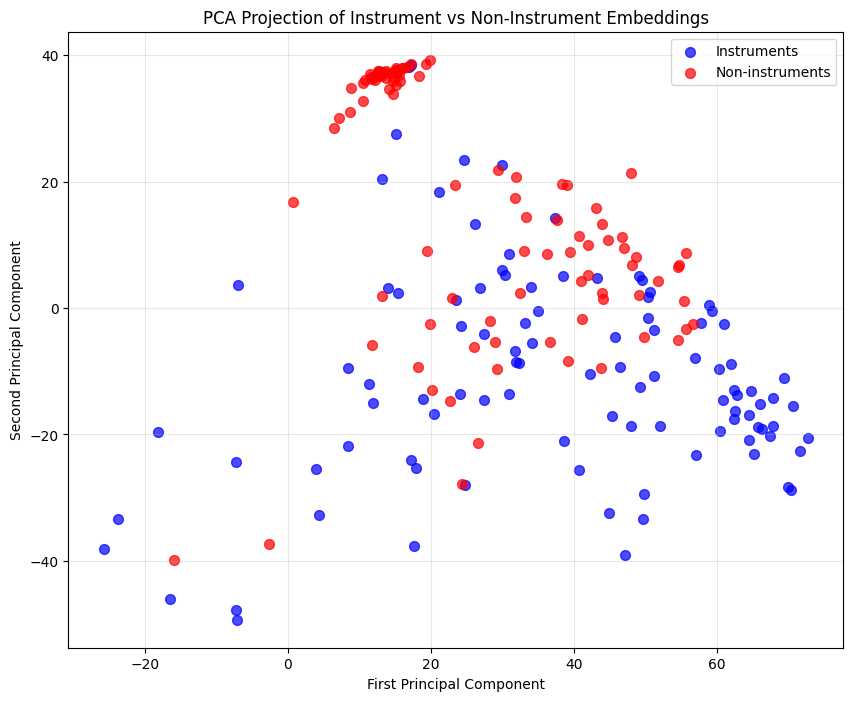

Explained variance ratio: [0.16515906 0.08562277]
Total variance explained: 0.251


In [19]:
import matplotlib.pyplot as plt

# Project all vectors onto the 2D subspace
instrument_proj = X_instruments @ instrument_basis.T
control_proj = X_control @ instrument_basis.T

plt.figure(figsize=(10, 8))
plt.scatter(instrument_proj[:, 0], instrument_proj[:, 1], 
           alpha=0.7, s=50, c='blue', label='Instruments')
plt.scatter(control_proj[:, 0], control_proj[:, 1], 
           alpha=0.7, s=50, c='red', label='Non-instruments')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Projection of Instrument vs Non-Instrument Embeddings')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

In [ ]:
mt.tokenizer.decode(get_repr_vec(cat_idx[0], mt))

TypeError: argument 'ids': 'float' object cannot be interpreted as an integer